# **Klasifikasi Hewan Kucing dan Anjing | K - Nearest Neighbours**

Klasifikasi hewan kucing atau anjing, berdasarkan karakteristik tertentu.

## 1. Data Preparation

### 1.1 Import Libarary


In [777]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Import & Understanding Data

In [778]:
# Import cat_dog_classifier.csv dataset
animals = pd.read_csv('cat_dog_classifier.csv')


In [779]:
# Tamplikan 5 baris teratas
print('\n5 baris teratas:')
animals.head()


5 baris teratas:


,Height;Weight;Length;FurLength;PawSize;EarShape;Animal
0,25;4;30;Short;Small;Round;Cat
1,32;6;38;Medium;Medium;Triangular;Cat
2,38;8;45;Long;Large;Medium;Dog
3,28;5;35;Short;Small;Round;Cat
4,35;7;42;Medium;Medium;Triangular;Dog


In [780]:
# Import cat_dog_classifier.csv dataset
animals = pd.read_csv('cat_dog_classifier.csv', sep=';')

In [781]:
# Tamplikan 5 baris teratas
print('\n5 baris teratas:')
animals.head()


5 baris teratas:


,Height,Weight,Length,FurLength,PawSize,EarShape,Animal
0,25,4,30,Short,Small,Round,Cat
1,32,6,38,Medium,Medium,Triangular,Cat
2,38,8,45,Long,Large,Medium,Dog
3,28,5,35,Short,Small,Round,Cat
4,35,7,42,Medium,Medium,Triangular,Dog


In [782]:
# Tampilkan informasi dataset
print('\nInformasi dataset:')
animals.info()


Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Height     49 non-null     int64 
 1   Weight     49 non-null     int64 
 2   Length     49 non-null     int64 
 3   FurLength  49 non-null     object
 4   PawSize    49 non-null     object
 5   EarShape   49 non-null     object
 6   Animal     49 non-null     object
dtypes: int64(3), object(4)
memory usage: 2.8+ KB


In [783]:
# Tampilkan dimensi dataset
print('\nDimensi dataset:')
print('Jumlah baris:', animals.shape[0])
print('Jumlah kolom:', animals.shape[1])


Dimensi dataset:
Jumlah baris: 49
Jumlah kolom: 7


In [784]:
# Tampilkan nilai unik dan jumlah 
print('\nNilai unik per fitur:\n')
for col in animals.columns:
    print(f'=== Nilai Unik Fitur {col} ===')
    print(f'Jumlah nilai unik:', animals[col].nunique())
    counts = animals[col].value_counts(dropna=False)
    print(f'Nilai unik:', animals[col].unique()) 
    print('\n')


Nilai unik per fitur:

=== Nilai Unik Fitur Height ===
Jumlah nilai unik: 20
Nilai unik: [25 32 38 28 35 30 31 34 29 36 27 33 26 40 60 55 45 65 50 42]


=== Nilai Unik Fitur Weight ===
Jumlah nilai unik: 15
Nilai unik: [ 4  6  8  5  7 10  9 11 12 15 30 25 18 35 20]


=== Nilai Unik Fitur Length ===
Jumlah nilai unik: 22
Nilai unik: [ 30  38  45  35  42  36  37  41  43  33  40  32  34  50  44 100  90  70
 110  80  65  55]


=== Nilai Unik Fitur FurLength ===
Jumlah nilai unik: 3
Nilai unik: ['Short' 'Medium' 'Long']


=== Nilai Unik Fitur PawSize ===
Jumlah nilai unik: 3
Nilai unik: ['Small' 'Medium' 'Large']


=== Nilai Unik Fitur EarShape ===
Jumlah nilai unik: 3
Nilai unik: ['Round' 'Triangular' 'Medium']


=== Nilai Unik Fitur Animal ===
Jumlah nilai unik: 3
Nilai unik: ['Cat' 'Dog' '2']




In [785]:
# Tampilkan penyebaran target
animals['Animal'].value_counts()

Animal
Dog    26
Cat    21
2       2
Name: count, dtype: int64

In [786]:
# Simpan fitur numerik dan katogero
num_cols = animals.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = animals.select_dtypes(include=['object', 'category']).columns.tolist()


print(num_cols)
print(cat_cols)

['Height', 'Weight', 'Length']
['FurLength', 'PawSize', 'EarShape', 'Animal']


### 1.3 Missing Value & Data Duplicated

#### 1.3.1 Missing value


In [787]:
# Tampilkan total nilai kosong
print('Total nilai kosong:', animals.isnull().sum().sum())

Total nilai kosong: 0


#### 1.3.2 Data Duplicated

In [788]:
# Tampilkan total data duplikat 
print('Total data duplikat', animals.duplicated().sum())

Total data duplikat 9


In [789]:
animals = animals.drop_duplicates(keep='first')

In [790]:
print('Total data duplikat setelah ditangani:', animals.duplicated().sum())

Total data duplikat setelah ditangani: 0


## 2. Exploratory Data Analysis

In [791]:
# Ringkasan statistik dataset 
print('\nRingkasan statistik:')
animals.describe()


Ringkasan statistik:


,Height,Weight,Length
count,40.000000,40.000000,40.000000
mean,35.075000,10.100000,45.975000
std,8.890754,6.923761,18.676034
min,25.000000,4.000000,30.000000
25%,29.750000,6.000000,35.750000
50%,32.000000,8.000000,39.000000
75%,36.500000,11.000000,44.250000
max,65.000000,35.000000,110.000000


pada fitur Weight dan Lenght, nilai max lumayan jauh dari nilai median. Yang mana, ini bisa terindikasi sebuah outlier.

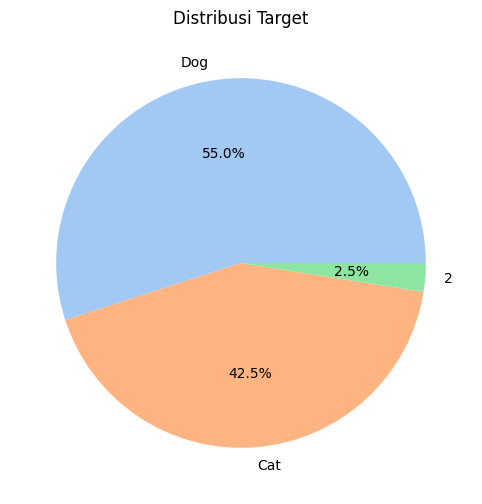

In [792]:
# Distribusi target
target_counts = animals['Animal'].value_counts()

colors = sns.color_palette('pastel')

plt.figure(figsize=(8,6))
plt.pie(
    target_counts,
    labels=target_counts.index,
    autopct="%1.1f%%",
    colors=colors,

)

plt.title('Distribusi Target')
plt.show()

Penyebaran target cukup merata, sehingga tidak diperlukan resampling.

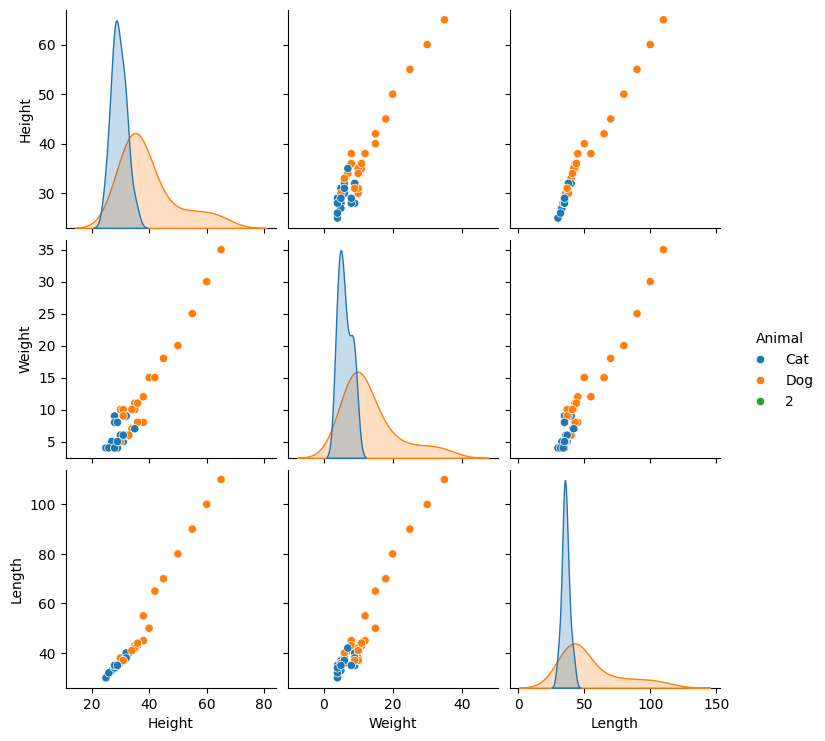

In [793]:
# Visualisasi pairplot
sns.pairplot(animals, hue='Animal')
plt.show()

Grafik ini memperlihatkan bahwa tidak ada pemisah daerah atau cluster yang jelas. 

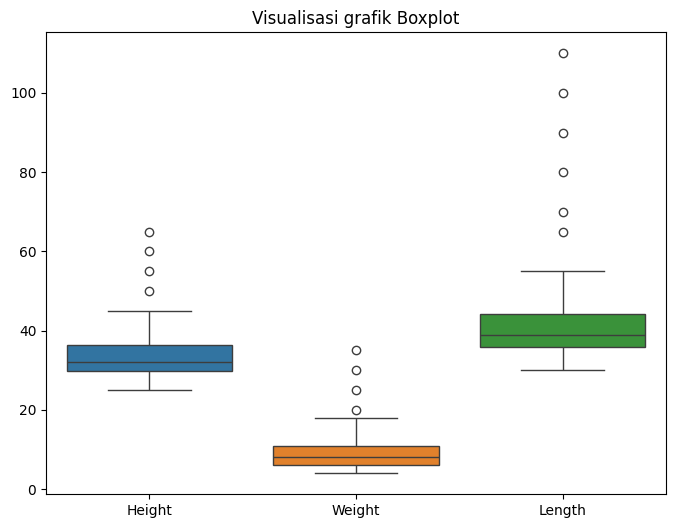

In [794]:
# Tampikan visuaisasi boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(animals)
plt.title('Visualisasi grafik Boxplot')
plt.show()

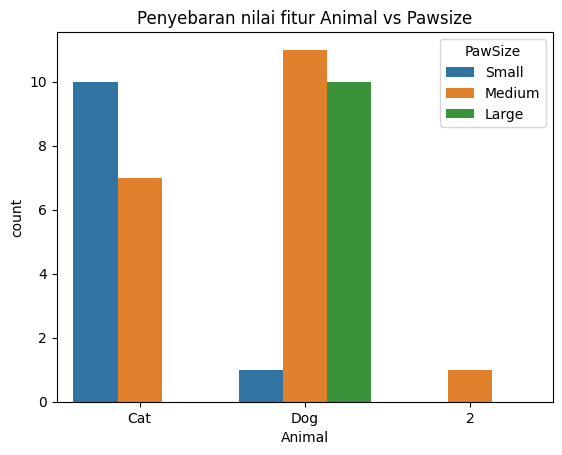

In [795]:


# Visualisasi dua kolom kategorikal (Hubungan)
sns.countplot(data=animals, x='Animal', hue='PawSize')
plt.title('Penyebaran nilai fitur Animal vs Pawsize')
plt.show()

In [796]:
obj_cols = animals.select_dtypes(include=['object']).columns

for col in obj_cols:
    # isi NaN dengan modus 
    mode_value = animals[col].mode()[0]       
    animals[col] = animals[col].fillna(mode_value)

    # encoding
    animals[col], uniques = pd.factorize(animals[col])

## 3. Model

In [798]:
X_before = animals.drop('Animal', axis=1)
y = animals['Animal']

In [799]:
# Normalisasi
X = (X_before - X_before.min()) / (X_before.max() - X_before.min())

# Standarisasi
# X = (X_before - X_before.mean()) / X_before.std()

In [800]:
np.random.seed(42)

idx_0 = np.where(y == 0)[0]
idx_1 = np.where(y == 1)[0]

np.random.shuffle(idx_0)
np.random.shuffle(idx_1)

train_0 = int(len(idx_0) * 0.8)
train_1 = int(len(idx_1) * 0.8)

train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

np.random.shuffle(train_idx)
np.random.shuffle(test_idx)

X_train = X.iloc[train_idx].values
X_test = X.iloc[test_idx].values
y_train = y.iloc[train_idx].values
y_test = y.iloc[test_idx].values

In [801]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (30, 6)
X_test : (9, 6)
y_train: (30,)
y_test : (9,)


In [802]:
def knn(X_train, y_train, X_test, k=3, metric='euclidian', weight='uniform'):

    if metric == 'euclidean':
        distance = np.sqrt(np.sum((X_train - X_test)**2, axis=1))
    elif metric == 'manhattan':
        distance = np.sum(np.abs(X_train - X_test), axis=1)
    elif metric == 'chebyshev':
        distance = np.max(np.abs(X_train - X_test), axis=1)


    # distance = np.sqrt(np.sum((X_train - X_test)**2, axis=1))
    sort = np.argsort(distance)
    nearest = sort[:k]
    nearest_label = y_train[nearest]
    nearest_dist = distance[nearest]

    if weight == 'uniform':
        label, count = np.unique(nearest_label.astype(int), return_counts=True)
        prediction = label[count.argmax()]
    
    elif weight == 'weighted':
        epsilon = 1e+5
        bobot = 1 / (nearest_dist + epsilon)
        total_bobot = np.bincount(nearest_label.astype(int), weights=bobot) 
        prediction = total_bobot.argmax()

    return prediction

In [803]:
metrics_list = ['euclidean', 'manhattan', 'chebyshev']
K_range = [3,5,7,9,11]
best_global_acc = 0
best_global_params = {}

for metric in metrics_list:
    accuracies = []
    
    for K in K_range:
        correct = 0
        for i in range(len(X_test)):
            pred = knn(X_train, y_train, X_test[i], k=K, metric=metric)
            
            if pred == y_test[i]:
                correct += 1
        
        acc = correct / len(X_test)
        accuracies.append(acc)
        
    best_k_idx = np.argmax(accuracies)
    best_k_metric = K_range[best_k_idx]
    best_acc_metric = accuracies[best_k_idx]
    
    print(f"{metric}    : K={best_k_metric}, Akurasi: {best_acc_metric:.4f}")
    
    if best_acc_metric > best_global_acc:
        best_global_acc = best_acc_metric
        best_global_params = {'metric': metric, 'k': best_k_metric}
        
print(f"\nMetric : {best_global_params['metric']}")
print(f"K      : {best_global_params['k']}")
print(f"Akurasi: {best_global_acc:.4f}")

euclidean    : K=5, Akurasi: 0.7778
manhattan    : K=3, Akurasi: 0.7778
chebyshev    : K=7, Akurasi: 0.7778

Metric : euclidean
K      : 5
Akurasi: 0.7778


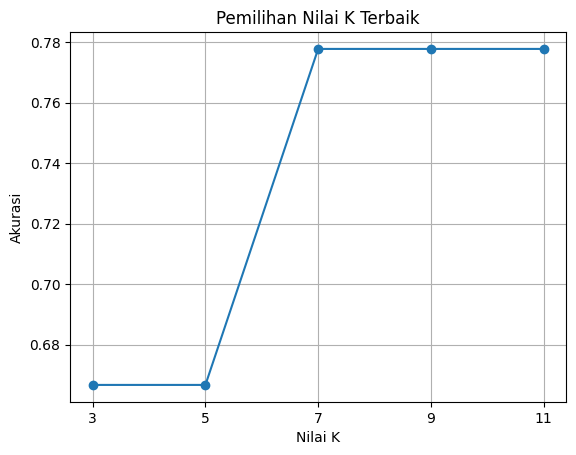

In [804]:
plt.plot(K_range, accuracies, marker='o')
plt.grid(True)
plt.xticks(K_range)
plt.xlabel('Nilai K')
plt.ylabel('Akurasi')
plt.title('Pemilihan Nilai K Terbaik')
plt.show()

In [810]:
voting_method = ['uniform', 'weighted']
result = {}

for method in voting_method:
    correct = 0
    total = len(X_test)

    for i in range(total):
        pred = knn(X_train, y_train, X_train[i], k=best_k_metric, metric='euclidean', weight=method)
        if pred == y_test[i]:
            correct += 1
    acc = correct / total
    result[method] = acc
    print(f'Metode  : {method}, akurasi : {acc:.4f}')

Metode  : uniform, akurasi : 0.2222
Metode  : weighted, akurasi : 0.2222


In [ ]:
y_pred = []
train_pred = []

for i in range(len(X_test)):
    test = knn(X_train, y_train, X_test[i], k=best_k_metric, metric='euclidean', weight='weighted')
    train = knn(X_train, y_train, X_test[i], k=best_k_metric, metric='euclidean', weight='weighted')
    
    y_pred.append(test)
    train_pred.append(train)

In [815]:
def classification_report(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    total_cases = tp + tn + fp + fn
    accuracy = (tp + tn) / total_cases if total_cases > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("HASIL EVALUASI\n")
    print(f"Recall          : {recall:.2%}")
    print(f"Precision       : {precision:.2%}")
    print(f"F1-Score        : {f1:.2%}")
    print(f"Akurasi         : {accuracy:.2%}")
    return recall, precision, f1, accuracy

# Jalankan evaluasi
recall, prec, f1, acc = classification_report(y_test, y_pred)

def prediksi(X, y, k_value):
    correct = 0
    total = len(X)

    for i in range(total):
        pred = knn(X_train, y_train, X[i], k=k_value, metric='euclidean', weight='weighted')
        if pred == y[i]:
            correct += 1
    return correct / total

train_acc = prediksi(X_train, y_train, best_k_metric)
test_acc = prediksi(X_test, y_test, best_k_metric)

print(f'\nAkurasi train   : {train_acc:.2%}')
print(f'Akurasi test    : {test_acc:.2%}')

HASIL EVALUASI

Recall          : 80.00%
Precision       : 80.00%
F1-Score        : 80.00%
Akurasi         : 77.78%

Akurasi train   : 86.67%
Akurasi test    : 77.78%


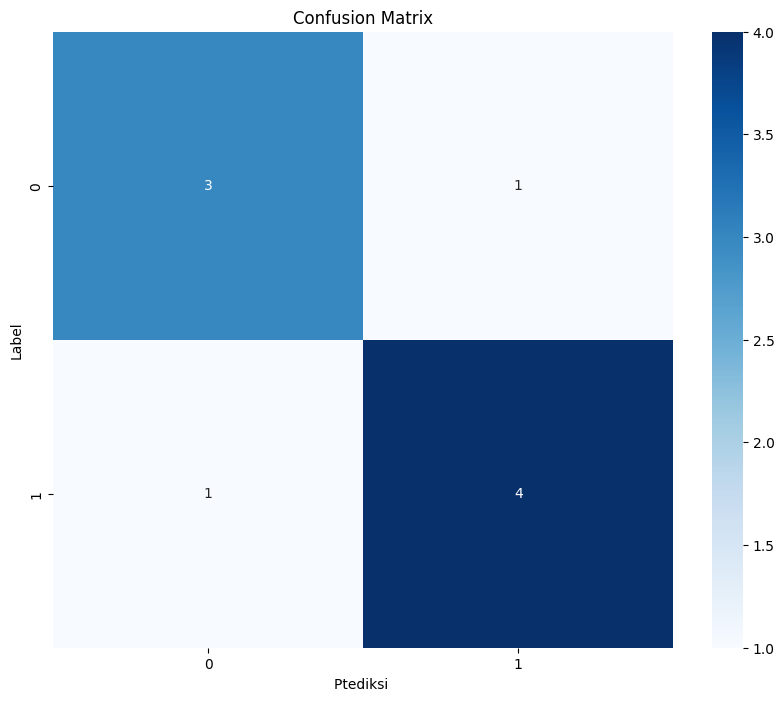

In [816]:
def confusion_matrix_manual(y_true, y_pred):
    labels = np.unique(np.concatenate((y_true, y_pred)))
    label_to_idx = {label: i for i, label in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=int)

    for yt, yp in zip(y_true, y_pred):
        i = label_to_idx[yt]   
        j = label_to_idx[yp]   
        cm[i, j] += 1

    return cm, labels

plt.figure(figsize=(10,8))
cm, labels = confusion_matrix_manual(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Ptediksi ")
plt.ylabel("Label")
plt.title("Confusion Matrix")
plt.show()

## No

In [809]:
# accuracies = []
# K_range = [3,5,7,9,11]

# for K in K_range:
#     correct = 0
#     for i in range(len(X_test)):
#         pred = knn(X_train, y_train, X_test[i], k=K)
#         if pred == y_test[i]:
#             correct += 1
#     acc = correct / len(X_test)
#     accuracies.append(acc)
#     print(f'K   : {K:2d}, accuracy      : {acc:.4f}')

# best_k = K_range[np.argmax(accuracies)]
# print(f'Best K  : {best_k}, accuracy : {max(accuracies):.4f}')